Importing libraries

In [37]:
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

Plotting style

In [38]:
sns.set_theme(style="white", palette="muted", font_scale=1.1)
plt.rcParams['axes.labelsize'] = 16       # Axis labels
plt.rcParams['xtick.labelsize'] = 14      # X-axis digits
plt.rcParams['ytick.labelsize'] = 14      # Y-axis digits
plt.rcParams['legend.fontsize'] = 12      # Legend text
plt.rcParams['figure.titlesize'] = 18     # Figure super titles

EPS = 1e-9 # Small epsilon for numerical stability

Functions

In [39]:
def strain_kinematics(t, gamma0, omega):
    """Generates a sinusoidal strain wave."""
    return gamma0 * np.sin(omega * t)

def strain_rate_kinematics(t, gamma0, omega):
    """Generates a sinusoidal strain rate wave."""
    return gamma0 * omega * np.cos(omega * t)

Stage 1: Fitting to Kelvin-Voigt

In [40]:
print("--- PART 1: Fitting Kelvin-Voigt to Low-Strain Data ---")
XLSX_FILE_PATH_LOW_STRAIN = '/content/40att1.xlsx'
STRAIN_COLUMN_NAME = 'Strain'
STRESS_COLUMN_NAME = 'Stress'
omega_low_strain = 10.0 # rad/s

G_unyielded_phys = None
eta_p_unyielded_phys = None
low_strain_results = {} # To store results for final plotting

try:
    df_low_strain = pd.read_excel(XLSX_FILE_PATH_LOW_STRAIN)
    print(f"Successfully loaded low-strain data: {XLSX_FILE_PATH_LOW_STRAIN}")

    strain_low_phys_np = df_low_strain[STRAIN_COLUMN_NAME].values
    stress_low_phys_np = df_low_strain[STRESS_COLUMN_NAME].values

    t_low_phys_np = np.linspace(0, (2 * np.pi / omega_low_strain), len(strain_low_phys_np), endpoint=False)
    strain_rate_low_phys_np = np.gradient(strain_low_phys_np, t_low_phys_np)

    # Fit Kelvin-Voigt directly to physical data: sigma = G * gamma + eta * gammadot
    print("Fitting physical data with Kelvin-Voigt model (sigma = G*gamma + eta*gammadot)...")
    X_fit_phys = np.vstack([strain_low_phys_np, strain_rate_low_phys_np]).T
    Y_fit_phys = stress_low_phys_np

    kv_model = LinearRegression(fit_intercept=False)
    kv_model.fit(X_fit_phys, Y_fit_phys)

    G_unyielded_phys = kv_model.coef_[0]
    # In Kelvin-Voigt, the viscous part corresponds to the material viscosity eta_p
    eta_unyielded_phys = kv_model.coef_[1]

    print("\n--- Unyielded Physical Parameters from Kelvin-Voigt Fit ---")
    print(f"G_unyielded: {G_unyielded_phys:.4f} Pa")
    print(f"eta_p_unyielded: {eta_p_unyielded_phys:.4f} Pa.s")

    # Visualize the fit and store results for later
    stress_predicted_low_phys = G_unyielded_phys * strain_low_phys_np + eta_p_unyielded_phys * strain_rate_low_phys_np

    low_strain_results = {
        'gamma0_label': 0.01,
        'strain_exp': strain_low_phys_np,
        'stress_exp': stress_low_phys_np,
        'stress_pred': stress_predicted_low_phys,
        'model_type': 'Kelvin-Voigt'
    }

    plt.figure(figsize=(8, 5))
    plt.plot(strain_low_phys_np, stress_low_phys_np, 'o', markersize=4, label='Experimental Data (γ₀ ≈ 0.01)')
    plt.plot(strain_low_phys_np, stress_predicted_low_phys, '-', linewidth=2, label='Kelvin-Voigt Fit')
    plt.xlabel('Strain (-)', fontsize=16)
    plt.ylabel('Stress (Pa)', fontsize=16)
    plt.title('Stage 1: Kelvin-Voigt Fit to Low Strain Data', fontsize=16)
    plt.legend(frameon=False, fontsize=12)
    # Removed grid
    plt.show()

except FileNotFoundError:
    print(f"ERROR: Low-strain data file not found: {XLSX_FILE_PATH_LOW_STRAIN}. Cannot determine unyielded parameters.")
except Exception as e:
    print(f"An error occurred during Stage 1 (Kelvin-Voigt fitting): {e}")

print("\n\n========================================================")
print("--- PART 2: Fitting Saramito Model to High-Strain Data ---")
print("========================================================")

--- PART 1: Fitting Kelvin-Voigt to Low-Strain Data ---
Successfully loaded low-strain data: /content/40att1.xlsx
Fitting physical data with Kelvin-Voigt model (sigma = G*gamma + eta*gammadot)...

--- Unyielded Physical Parameters from Kelvin-Voigt Fit ---
G_unyielded: 9666.2980 Pa
An error occurred during Stage 1 (Kelvin-Voigt fitting): unsupported format string passed to NoneType.__format__


--- PART 2: Fitting Saramito Model to High-Strain Data ---


Stage 2: Neural network + Learnable model's parameters

In [41]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.fc1 = nn.Linear(1, 50)
        self.fc2 = nn.Linear(50, 50)
        self.fc_tau = nn.Linear(50, 1)
        # Trainable parameters (raw) in scaled space
        self.lambda_raw = nn.Parameter(torch.tensor(0.001))
        self.eta_p_raw = nn.Parameter(torch.tensor(0.01))
        self.eta_raw = nn.Parameter(torch.tensor(0.01))
        self.tau_0_raw = nn.Parameter(torch.tensor(0.001))

    def forward(self, x):
        # 2-layer MLP for total_stress_pred
        x = torch.relu(self.fc1(x)); x = torch.relu(self.fc2(x))
        return self.fc_tau(x)

    def get_parameters(self):
        """Return non-negative parameters in *scaled* domain."""
        return (torch.relu(self.lambda_raw), torch.relu(self.eta_p_raw),
                torch.relu(self.eta_raw), torch.relu(self.tau_0_raw))

Loss function

In [42]:
def loss_function(total_stress_pred, y_true, lambda_, tau_0, eta_p, eta,
                  strain_rate_scaled, t_tensor_scaled):
    """Calculates loss in the scaled domain."""
    tau_pred = total_stress_pred - eta * strain_rate_scaled
    abs_tau = torch.abs(tau_pred)
    # Add a small epsilon to the denominator to prevent division by zero
    max_term = torch.where(abs_tau > tau_0, (abs_tau - tau_0) / (abs_tau + EPS),
                           torch.tensor(0.0, dtype=torch.float32, device=abs_tau.device))
    dt_scaled = t_tensor_scaled[1, 0] - t_tensor_scaled[0, 0] if len(t_tensor_scaled) > 1 else 1.0
    dtau_dt = (eta_p * strain_rate_scaled - max_term * tau_pred) / (lambda_ + EPS)
    tau_cumsum = torch.cumsum(dtau_dt * dt_scaled, dim=0) + tau_pred[0]
    stress_comp = eta * strain_rate_scaled + tau_cumsum
    data_loss = torch.mean((y_true - total_stress_pred) ** 2)
    eq_loss = torch.mean((y_true - stress_comp) ** 2) + torch.mean((tau_cumsum - tau_pred) ** 2)
    return data_loss + eq_loss, data_loss, eq_loss

Learning rate adjustment

In [43]:
def warmup_then_cosine_lr(epoch, total_epochs, warmup_epochs=100,
                          initial_lr=5e-4, max_lr=5e-4, min_lr=1e-6):
    if epoch < warmup_epochs:
        return initial_lr + (max_lr - initial_lr) * (epoch / float(warmup_epochs))
    else:
        progress = (epoch - warmup_epochs) / float(total_epochs - warmup_epochs)
        return min_lr + 0.5 * (max_lr - min_lr) * (1 + math.cos(math.pi * progress))

Stage 2: Loading nonlinear data and define mutual paramters





In [44]:

experiments_high_strain = [
    {'filepath': '/content/40att10.xlsx', 'gamma0_label': 0.1},
    {'filepath': '/content/40att30.xlsx', 'gamma0_label': 0.3},
    {'filepath': '/content/40att50.xlsx', 'gamma0_label': 0.5},
    {'filepath': '/content/40att100.xlsx', 'gamma0_label': 1.0}
]
omega_high_strain = 10.0
# Ensure these match your actual column names
STRAIN_COLUMN_NAME = 'Strain'
STRESS_COLUMN_NAME = 'Stress'
EPS = 1e-8

processed_experiments = []

print("--- Step 1: Data Loading and Normalization ---")

for exp_info in experiments_high_strain:
    filepath = exp_info['filepath']
    gamma0_label = exp_info['gamma0_label']

    try:
        # 1. Load Data
        df = pd.read_excel(filepath)

        # 2. Derived Physics
        t = np.linspace(0, 2*np.pi/omega_high_strain, len(df))
        strain = df[STRAIN_COLUMN_NAME].values
        stress = df[STRESS_COLUMN_NAME].values
        strainrate = np.gradient(strain, t)
        print(f"Loaded {filepath} ({len(df)} points).")

        # 3. Tensor Creation
        t_tensor = torch.tensor(t, dtype=torch.float32).view(-1, 1)
        strain_tensor = torch.tensor(strain, dtype=torch.float32).view(-1, 1)
        strainrate_tensor = torch.tensor(strainrate, dtype=torch.float32).view(-1, 1)
        stress_tensor = torch.tensor(stress, dtype=torch.float32).view(-1, 1)

        # 4. Normalization (Scaling)
        scaler_t = MinMaxScaler(feature_range=(-1, 1))
        t_tensor_scaled = torch.tensor(scaler_t.fit_transform(t_tensor), dtype=torch.float32)

        scaler_strain = MinMaxScaler(feature_range=(-1, 1))
        strain_tensor_scaled = torch.tensor(scaler_strain.fit_transform(strain_tensor), dtype=torch.float32)

        scaler_strainrate = MinMaxScaler(feature_range=(-1, 1))
        strainrate_tensor_scaled = torch.tensor(scaler_strainrate.fit_transform(strainrate_tensor), dtype=torch.float32)

        scaler_stress = MinMaxScaler(feature_range=(-1, 1))
        stress_tensor_scaled = torch.tensor(scaler_stress.fit_transform(stress_tensor), dtype=torch.float32)

        # Store processed data for the training cell
        processed_experiments.append({
            'label': gamma0_label,
            'raw_data': {'t': t, 'strain': strain, 'stress': stress, 'strainrate': strainrate},
            'tensors': {
                't': t_tensor_scaled,
                'strain': strain_tensor_scaled,
                'strainrate': strainrate_tensor_scaled,
                'stress': stress_tensor_scaled
            },
            'scalers': {
                't': scaler_t,
                'stress': scaler_stress,
                'strainrate': scaler_strainrate
            }
        })

    except FileNotFoundError:
        print(f"ERROR: File not found: {filepath}. Skipping.")
    except KeyError as e:
        print(f"ERROR: Column {e} not found in {filepath}. Skipping.")

--- Step 1: Data Loading and Normalization ---
Loaded /content/40att10.xlsx (313 points).
Loaded /content/40att30.xlsx (307 points).
Loaded /content/40att50.xlsx (305 points).
Loaded /content/40att100.xlsx (305 points).


Learning rate adjustment

In [45]:
import math

print("--- Step 2: Learning Rate Scheduler Setup ---")

# Hyperparameters
num_epochs = 10000
loss_threshold = 0.004

# Scheduler configuration
lr_params = {
    'warmup_epochs': 200,
    'initial_lr': 5e-5,
    'max_lr': 5e-4,
    'min_lr': 1e-6
}

def warmup_then_cosine_lr(epoch, num_epochs, warmup_epochs, initial_lr, max_lr, min_lr):
    """
    Calculates the learning rate based on linear warmup followed by cosine annealing.
    """
    if epoch < warmup_epochs:
        # Linear warmup phase
        lr = initial_lr + (max_lr - initial_lr) * (epoch / warmup_epochs)
    else:
        # Cosine annealing phase
        progress = (epoch - warmup_epochs) / (num_epochs - warmup_epochs)
        lr = min_lr + 0.5 * (max_lr - min_lr) * (1 + math.cos(math.pi * progress))
    return lr

--- Step 2: Learning Rate Scheduler Setup ---


Training

In [46]:
import torch.optim as optim

print("--- Step 3: Training ---")

saramito_results = []

for exp_data in processed_experiments:
    gamma0_label = exp_data['label']
    print(f"\n--- Starting PINN fit for γ₀ ≈ {gamma0_label} ---")

    # Retrieve prepared tensors
    t_scaled = exp_data['tensors']['t']
    stress_scaled = exp_data['tensors']['stress']
    strainrate_scaled = exp_data['tensors']['strainrate']

    # Initialize Model & Optimizer
    model = PINN()
    optimizer = optim.Adam(model.parameters(), lr=lr_params['max_lr'], weight_decay=5e-5)

    loss_values = []

    # --- Training Loop ---
    for epoch in range(num_epochs):
        # 1. Update Learning Rate
        lr_current = warmup_then_cosine_lr(epoch, num_epochs, **lr_params)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr_current

        # 2. Forward Pass
        model.train()
        optimizer.zero_grad()

        total_stress_pred = model(t_scaled)
        lambda_, eta_p, eta, tau_0 = model.get_parameters()

        # Calculate Loss
        total_loss, data_loss, eq_loss = loss_function(
            total_stress_pred, stress_scaled, lambda_, tau_0, eta_p, eta,
            strainrate_scaled, t_scaled
        )

        # 3. Backward Pass
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        loss_values.append(total_loss.item())

        # Logging
        if epoch % (num_epochs // 4) == 0:
            print(f"  Epoch {epoch:5d} | Total Loss={total_loss.item():.3e} | LR={lr_current:.2e}")

        if total_loss.item() < loss_threshold:
            print(f"  Stopping early at epoch {epoch}")
            break

    # --- Evaluation & Rescaling ---
    model.eval()
    with torch.no_grad():
        total_stress_pred_scaled = model(t_scaled)
        lambda_scaled, eta_p_scaled, eta_scaled, tau_0_scaled = model.get_parameters()

    # Retrieve specific scalers for this experiment
    scaler_t = exp_data['scalers']['t']
    scaler_stress = exp_data['scalers']['stress']
    scaler_strainrate = exp_data['scalers']['strainrate']

    # Unscale Physics Parameters
    time_half_range = (scaler_t.data_max_[0] - scaler_t.data_min_[0]) / 2.0
    stress_half_range = (scaler_stress.data_max_[0] - scaler_stress.data_min_[0]) / 2.0
    strainrate_half_range = (scaler_strainrate.data_max_[0] - scaler_strainrate.data_min_[0]) / 2.0

    lambda_orig = lambda_scaled.item() * time_half_range
    tau_0_orig  = tau_0_scaled.item()  * stress_half_range
    eta_orig    = eta_scaled.item()    * (stress_half_range / (strainrate_half_range + EPS))
    eta_p_orig  = eta_p_scaled.item()  * (stress_half_range / (strainrate_half_range + EPS))
    G_effective = eta_p_orig / (lambda_orig + EPS) if lambda_orig > EPS else 0

    total_stress_pred_unscaled = scaler_stress.inverse_transform(total_stress_pred_scaled.numpy())

    saramito_results.append({
        'gamma0_label': gamma0_label,
        'strain_exp': exp_data['raw_data']['strain'],
        'stress_exp': exp_data['raw_data']['stress'],
        'stress_pred': total_stress_pred_unscaled.flatten(),
        'model_type': 'Saramito',
        'params': {
            'lambda': lambda_orig, 'tau_0': tau_0_orig,
            'eta_p': eta_p_orig, 'eta': eta_orig,
            'G_effective': G_effective
        }
    })
    print(f"--- Fit for γ₀ ≈ {gamma0_label} complete. ---")

--- Step 3: Training ---

--- Starting PINN fit for γ₀ ≈ 0.1 ---
  Epoch     0 | Total Loss=1.033e+04 | LR=5.00e-05
  Epoch  2500 | Total Loss=1.315e-02 | LR=4.35e-04
  Epoch  5000 | Total Loss=5.850e-03 | LR=2.58e-04
  Epoch  7500 | Total Loss=4.993e-03 | LR=7.69e-05
--- Fit for γ₀ ≈ 0.1 complete. ---

--- Starting PINN fit for γ₀ ≈ 0.3 ---
  Epoch     0 | Total Loss=7.428e+02 | LR=5.00e-05
  Epoch  2500 | Total Loss=3.721e-02 | LR=4.35e-04
  Epoch  5000 | Total Loss=2.487e-02 | LR=2.58e-04
  Epoch  7500 | Total Loss=1.874e-02 | LR=7.69e-05
--- Fit for γ₀ ≈ 0.3 complete. ---

--- Starting PINN fit for γ₀ ≈ 0.5 ---
  Epoch     0 | Total Loss=8.370e+03 | LR=5.00e-05
  Epoch  2500 | Total Loss=6.365e-02 | LR=4.35e-04
  Epoch  5000 | Total Loss=4.990e-02 | LR=2.58e-04
  Epoch  7500 | Total Loss=4.203e-02 | LR=7.69e-05
--- Fit for γ₀ ≈ 0.5 complete. ---

--- Starting PINN fit for γ₀ ≈ 1.0 ---
  Epoch     0 | Total Loss=3.364e+04 | LR=5.00e-05
  Epoch  2500 | Total Loss=8.196e-02 | LR=4.35e

Plots and report

In [47]:
print("\n--- Summary of Results ---")

print("\nUnyielded Parameters (from Kelvin-Voigt fit on low-strain data):")
if G_unyielded_phys is not None and eta_p_unyielded_phys is not None:
    print(f"  - G_unyielded: {G_unyielded_phys:.2f} Pa")
    print(f"  - η_p_unyielded: {eta_p_unyielded_phys:.2f} Pa.s")
else:
    print("  - Could not be determined.")

print("\nFitted Saramito Parameters for High-Strain Data:")
print(f"{'Strain Amp (γ₀)':<20} | {'lambda (s)':<15} | {'eta_p (Pa.s)':<15} | {'tau_0 (Pa)':<15} | {'eta (Pa.s)':<15} | {'G (Pa)':<20}")
print("-" * 110)
for res in saramito_results:
    p = res['params']
    print(f"{res['gamma0_label']:<20.2f} | {p['lambda']:<15.4f} | {p['eta_p']:<15.2f} | {p['tau_0']:<15.2f} | {p['eta']:<15.2f} | {p['G_effective']:<20.2f}")


--- Summary of Results ---

Unyielded Parameters (from Kelvin-Voigt fit on low-strain data):
  - Could not be determined.

Fitted Saramito Parameters for High-Strain Data:
Strain Amp (γ₀)      | lambda (s)      | eta_p (Pa.s)    | tau_0 (Pa)      | eta (Pa.s)      | G (Pa)              
--------------------------------------------------------------------------------------------------------------
0.10                 | 0.0300          | 184.78          | 177.90          | 0.00            | 6161.30             
0.30                 | 0.0114          | 49.10           | 192.53          | 28.86           | 4311.36             
0.50                 | 0.0102          | 33.78           | 160.56          | 29.59           | 3325.20             
1.00                 | 0.0058          | 18.51           | 162.46          | 19.04           | 3170.66             


Pipkin diagram


--- Generating Pipkin-like Diagram ---


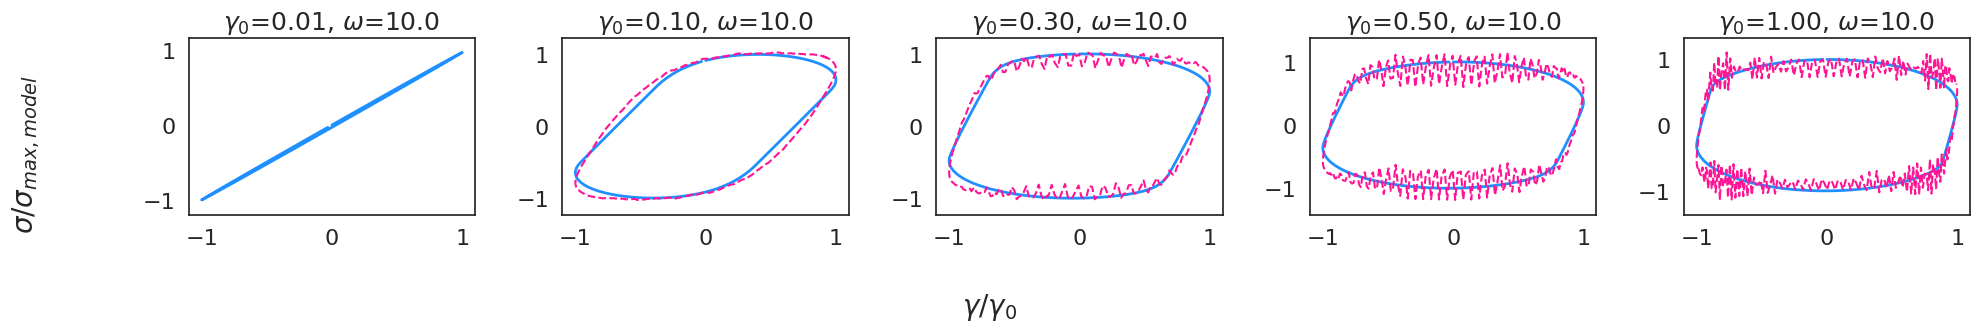

In [48]:
def compute_stress_physical_params(t_array, strainrate_array, lambda_val, eta_p_val, eta_val, tau_0_val):
    dt_val = t_array[1] - t_array[0] if len(t_array) > 1 else 1.0
    tau_arr = np.zeros_like(t_array)
    for i in range(1, len(t_array)):
        tau_prev = tau_arr[i-1]
        abs_tau = abs(tau_prev)
        max_term = max(0, (abs_tau - tau_0_val) / (abs_tau + EPS))
        dtau_dt = (eta_p_val * strainrate_array[i] - max_term * tau_prev) / (lambda_val + EPS)
        tau_arr[i] = tau_prev + dtau_dt * dt_val
    return tau_arr + eta_val * strainrate_array

print("\n--- Generating Pipkin-like Diagram ---")
pipkin_omegas = [10.0]
pipkin_gammas = [0.01, 0.1, 0.3, 0.5, 1.0]

n_rows, n_cols = len(pipkin_omegas), len(pipkin_gammas)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.0, n_rows * 3.5), sharex=True, sharey=False) # sharey=False for dynamic limits
if n_rows == 1: axes = np.array([axes])
if n_cols == 1: axes = axes.reshape(-1,1)

all_results_for_pipkin = ([low_strain_results] if low_strain_results else []) + saramito_results

for i, omega_val in enumerate(pipkin_omegas):
    for j, gamma0_val in enumerate(pipkin_gammas):
        ax = axes[i, j]

        # --- Find closest set of learned parameters for the model prediction ---
        closest_exp = min(all_results_for_pipkin, key=lambda x: abs(x['gamma0_label'] - gamma0_val))

        # --- Generate Model Prediction ---
        num_cycles_sim = 3 # Simulate multiple cycles to discard transient
        points_per_cycle = 200 # Resolution for simulation

        t_sim_full = np.linspace(0, num_cycles_sim * 2 * np.pi / omega_val, num_cycles_sim * points_per_cycle, endpoint=False)
        strain_sim_full = strain_kinematics(t_sim_full, gamma0_val, omega_val)
        strain_rate_sim_full = strain_rate_kinematics(t_sim_full, gamma0_val, omega_val)

        # Use Kelvin-Voigt model for the lowest strain, otherwise use the full Saramito fit
        if gamma0_val <= 0.01 and 'Kelvin-Voigt' in closest_exp.get('model_type',''):
             stress_model_full = G_unyielded_phys * strain_sim_full + eta_p_unyielded_phys * strain_rate_sim_full
        else:
            p = closest_exp['params']
            stress_model_full = compute_stress_physical_params(t_sim_full, strain_rate_sim_full, p['lambda'], p['eta_p'], p['eta'], p['tau_0'])

        # --- Extract the SECOND cycle ---
        start_index = 1 * points_per_cycle # Start of the second cycle
        end_index = 2 * points_per_cycle   # End of the second cycle

        strain_model_cycle = strain_sim_full[start_index:end_index]
        stress_model_cycle = stress_model_full[start_index:end_index]

        if not np.all(np.isfinite(stress_model_cycle)): stress_model_cycle = np.nan_to_num(stress_model_cycle)

        # --- Normalize and Plot Model Prediction ---
        norm_strain_model = strain_model_cycle / (np.max(np.abs(strain_model_cycle)) + EPS)
        max_abs_model_stress = np.max(np.abs(stress_model_cycle))
        norm_stress_model = stress_model_cycle / (max_abs_model_stress + EPS)
        ax.plot(norm_strain_model, norm_stress_model, color='dodgerblue', linewidth=2, label='Model')

        y_vals_for_lim = [norm_stress_model]

        # --- Overlay Experimental Data if available ---
        # Only for omega = 10 rad/s row
        if abs(omega_val - 10.0) < 1e-6:
            for exp_res in all_results_for_pipkin:
                if abs(exp_res['gamma0_label'] - gamma0_val) < 1e-3:
                    norm_strain_exp = exp_res['strain_exp'] / (np.max(np.abs(exp_res['strain_exp']))+EPS)

                    norm_stress_exp = exp_res['stress_exp'] / (max_abs_model_stress + EPS)


                    ax.plot(norm_strain_exp, norm_stress_exp, '--', color=(1.0, 0.078, 0.576), linewidth=1.5, label='Experiment')


                    if abs(gamma0_val - 0.01) < 1e-3:
                         ax.legend(fontsize=14, frameon=False)

                    y_vals_for_lim.append(norm_stress_exp)
                    break

        # --- UPDATED PIPKIN STYLING ---
        ax.set_title(rf"$\gamma_0$={gamma0_val:.2f}, $\omega$={omega_val:.1f}", fontsize=18) # Subplot title fontsize
        # Removed grids and zero-lines
        ax.tick_params(axis='both', which='major', labelsize=16) # Axis number fontsize

        # --- Set dynamic y-limits ---
        all_finite_y = np.concatenate([arr[np.isfinite(arr)] for arr in y_vals_for_lim if arr.size > 0])
        if all_finite_y.size == 0: min_y, max_y = -1.1, 1.1
        else:
            min_y, max_y = np.min(all_finite_y), np.max(all_finite_y)
            y_range = max_y - min_y
            y_padding = y_range * 0.1 if y_range > EPS else 0.1
            min_y_lim, max_y_lim = min_y - y_padding, max_y + y_padding
        ax.set_ylim([min_y_lim, max_y_lim])
        ax.set_xlim([-1.1, 1.1])




fig.supxlabel(r"$\gamma/\gamma_0$", fontsize=20, y=0.02)
fig.supylabel(r"$\sigma/\sigma_{max,model}$", fontsize=20, x=0.01)
plt.tight_layout(rect=[0.03,0.03,1,0.97])
plt.show()